### Dados coletados do Kaggle (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Iremos utilizar esta base de dados para aprendizagem e aperfeiçoamento na área de dados,

Análises que iremos verificar:

-taxa de churn

-churn por tipo de contrato

-churn por faixa de preço

-churn por tempo de cliente


Como a seguir iremos visualizar as colunas do arquivo de dados, iremos deixar por escrito de acordo com o autor do Kaggle,

Do que se trata cada coluna:

* **gender**: Indica se o cliente é **masculino ou feminino**.

* **SeniorCitizen**: Indica se o cliente é **idoso (1) ou não (0)**.

* **tenure**: Número de **meses** que o cliente **permanece** com a empresa

* **Partner**: Indica se o cliente **possui parceiro(a)** ou não (**Sim, Não**).

* **Dependents**: Indica se o cliente **possui dependentes** ou não (**Sim, Não**).

* **PhoneService**: Indica se o cliente **possui serviço de telefone** ou não (**Sim, Não**).

* **MultipleLines**: Indica se o cliente **possui múltiplas linhas telefônicas** ou não (**Sim, Não, Sem serviço de telefone**).

* **InternetService**: **Tipo de provedor de internet** do cliente (**DSL, Fibra óptica, Nenhum**).

* **OnlineSecurity**: Indica se o cliente **possui serviço de segurança online** (**Sim, Não, Sem serviço de internet**).

* **OnlineBackup**: Indica se o cliente **possui backup online** (**Sim, Não, Sem serviço de internet**).

* **DeviceProtection**: Indica se o cliente **possui proteção para dispositivos** (**Sim, Não, Sem serviço de internet**).

* **TechSupport**: Indica se o cliente **possui suporte técnico** (**Sim, Não, Sem serviço de internet**).

* **StreamingTV**: Indica se o cliente **possui serviço de streaming de TV** (**Sim, Não, Sem serviço de internet**).

* **StreamingMovies**: Indica se o cliente **possui serviço de streaming de filmes** (**Sim, Não, Sem serviço de internet**).

* **Contract**: **Tipo de contrato** do cliente (**Mensal, Um ano, Dois anos**).

* **PaperlessBilling**: Indica se o cliente **utiliza faturamento sem papel (digital)** (**Sim, Não**).

* **PaymentMethod**: **Método de pagamento do cliente** (**Cheque eletrônico, Cheque enviado pelo correio, Transferência bancária automática, Cartão de crédito automático**)

* **MonthlyCharges**: **Valor cobrado mensalmente** do cliente.

* **TotalCharges**: **Valor total cobrado** do cliente ao longo do tempo.

* **Churn**: Indica se o cliente **cancelou o serviço (Sim) ou não (Não)**.


### Puxando a base de dados e visualizando a mesma

- Puxando os dados

In [1]:
import dados_1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from dados_1 import dados_arquivos
from importlib import reload
from limpeza_dados_3 import dados_tratados

- Visualizar dados

In [2]:
reload(dados_1)

<module 'dados_1' from 'd:\\Projetos\\Projeto Telco Churn\\dados_1.py'>

- Cnforme já realizado a limpeza anterior dos dados

Iremos puxar os mesmos

In [3]:
df = dados_arquivos()
df = dados_tratados(df)

- Aqui iremos separar as colunas em númericas e não númericas

In [4]:
colunas_numericas = df.select_dtypes(include='number').columns
colunas_categoricas = df.select_dtypes(exclude='number').columns
colunas_categoricas = colunas_categoricas.drop('Churn')

print(colunas_numericas)
print(colunas_categoricas)

df.head()

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Análise das variáveis numéricas

### Histogramas

- Um histograma é uma representação gráfica da distribuição de frequências de uma variável. Ele é um gráfico de barras onde cada barra representa uma classe ou intervalo de classe e a área de cada barra é proporcional à frequência da classe. O histograma é uma ferramenta útil para visualizar a forma da distribuição de uma variável. Ele permite identificar a presença de assimetria e a presença de outliers.

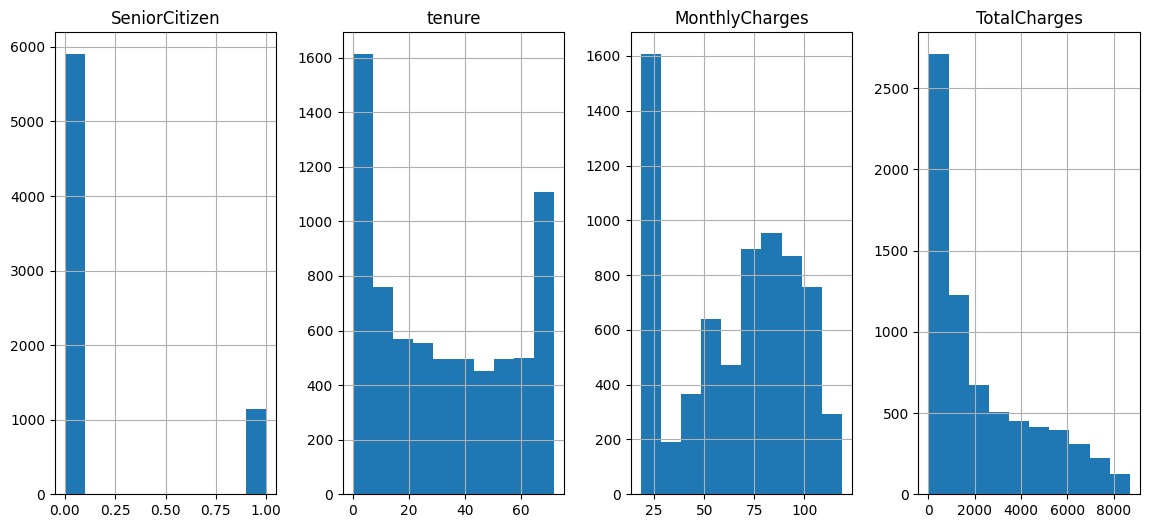

In [5]:
df[colunas_numericas].hist(layout=(1, 4), figsize=(14, 6));

Com o Seaborn, podemos plotar um histograma com a opção `hue` para separar os dados de acordo com uma variável categórica. Neste caso, vamos separar os dados de acordo com a variável `Contract`. Dessa forma, podemos comparar a distribuição de cada variável numérica de acordo com o tipo de contrato.

In [6]:
df['TotalCharges'].value_counts(bins=10).sort_index()

(10.133000000000001, 885.4]    2709
(885.4, 1752.0]                1228
(1752.0, 2618.6]                671
(2618.6, 3485.2]                508
(3485.2, 4351.8]                454
(4351.8, 5218.4]                412
(5218.4, 6085.0]                395
(6085.0, 6951.6]                310
(6951.6, 7818.2]                223
(7818.2, 8684.8]                122
Name: count, dtype: int64

- Verificando qual tipo de contrato é mais comum 

<Axes: xlabel='Contract', ylabel='count'>

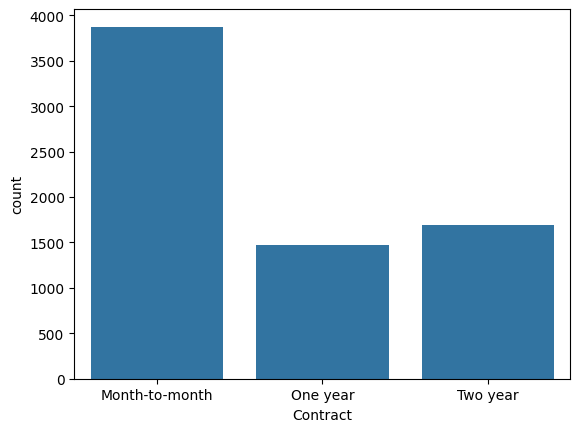

In [7]:
sns.countplot(data=df, x='Contract')

- Verificando churn por tipo de contrato

Analisando o gráfico fica visivel que a modalidade de contrato mês a mês é mais comum para o churn.

Assim os contratos de longos prazos, tendem a reter esses clientes com o "produto"

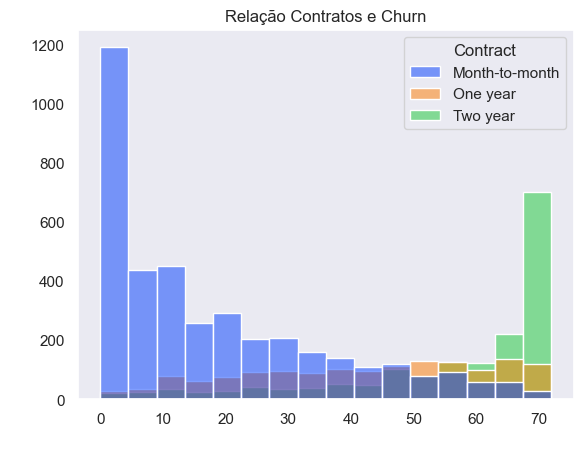

In [8]:
sns.set_theme(style='dark', palette='bright', context='notebook')
plt.title('Relação Contratos e Churn')
plt.xlabel(' ')
plt.ylabel(' ')
sns.histplot(x='tenure', data=df, hue='Contract');

- Verificando churn por metodo de pagamento

Utilizando o gráfico de churn por metodo de pagamento fica claro a discrepância entre pagamento automático por cartão de crédito e boleto

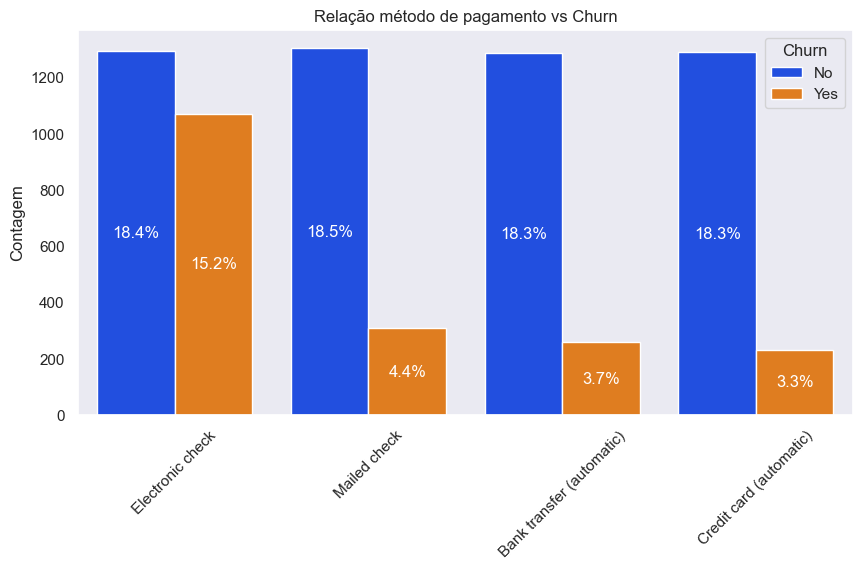

In [9]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn')

total = len(df)

for p in ax.patches:
    height = p.get_height()

    if height > 0:
        percentage = f'{100 * p.get_height()/total:.1f}%'
        x = p.get_x() + p.get_width()/2
        y = height/2
        ax.annotate(percentage, (x, y), ha='center', va='center', color='white')

plt.title('Relação método de pagamento vs Churn')
plt.xlabel('')
plt.ylabel('Contagem')
plt.xticks(rotation=45)

plt.show()

- Agora iremos separar as catégorias númericas para analise individual 

Verificando o gráfico é entendivel que pessoas que optam pelo cancelamento, tem menos "tempo de empresa".

Text(0, 0.5, '')

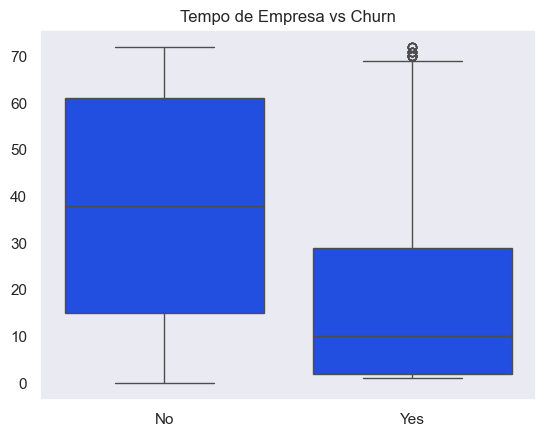

In [10]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tempo de Empresa vs Churn')
plt.xlabel('')
plt.ylabel('')

Verificando esse gráfico visualizamos que pagamentos alto afetam o cancelamento, aonde optam mais pelo desligamento.

Text(0, 0.5, '')

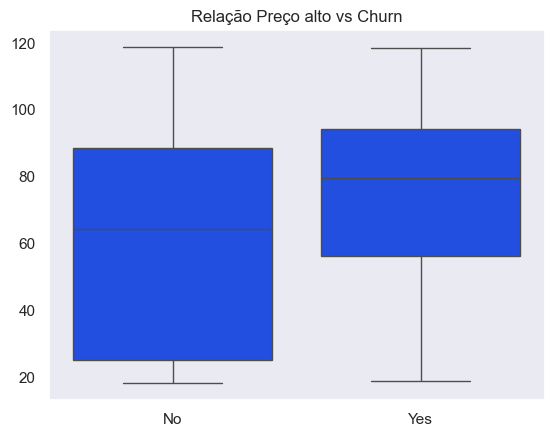

In [11]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Relação Preço alto vs Churn')
plt.xlabel('')
plt.ylabel('')


- Faixa de preço vs churn

 Nesse gráfico estamos tentando verificar se os planos com maior valor, tendem a cancelar mais

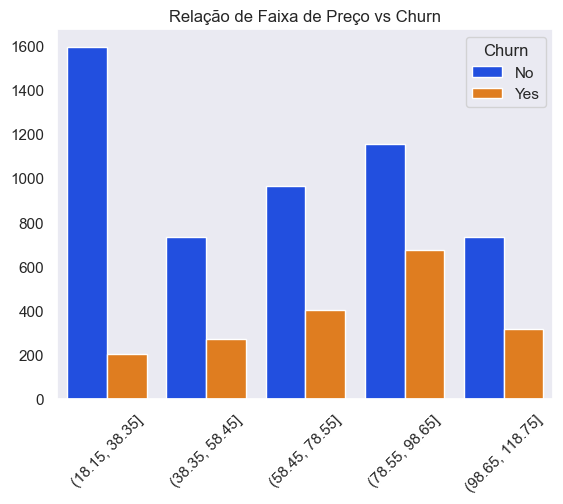

In [12]:
df['faixa_preco'] = pd.cut(df['MonthlyCharges'], bins=5);

sns.countplot(data=df, x='faixa_preco', hue='Churn');
plt.title('Relação de Faixa de Preço vs Churn')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45);

- Iremos utilizar um heatmap para verificar se possui algumas correlações entre os dados.

Com esse heatmap conseguimos identificar uma correlação do número de meses em tempo de empresa com o valor total cobrado

<Axes: >

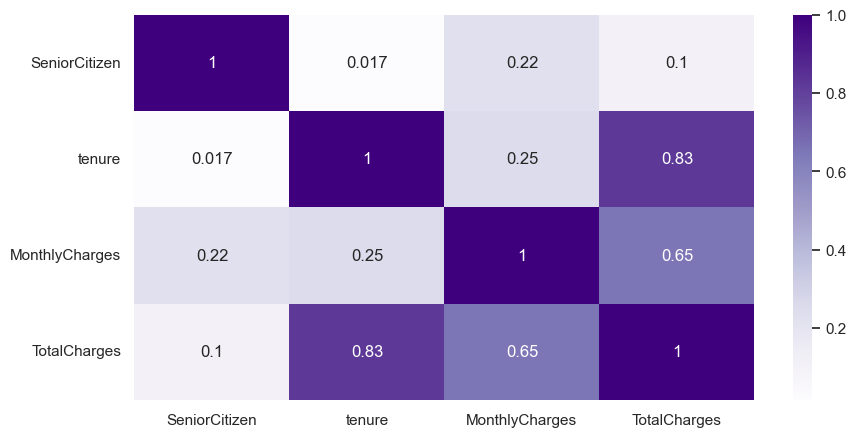

In [13]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Purples')

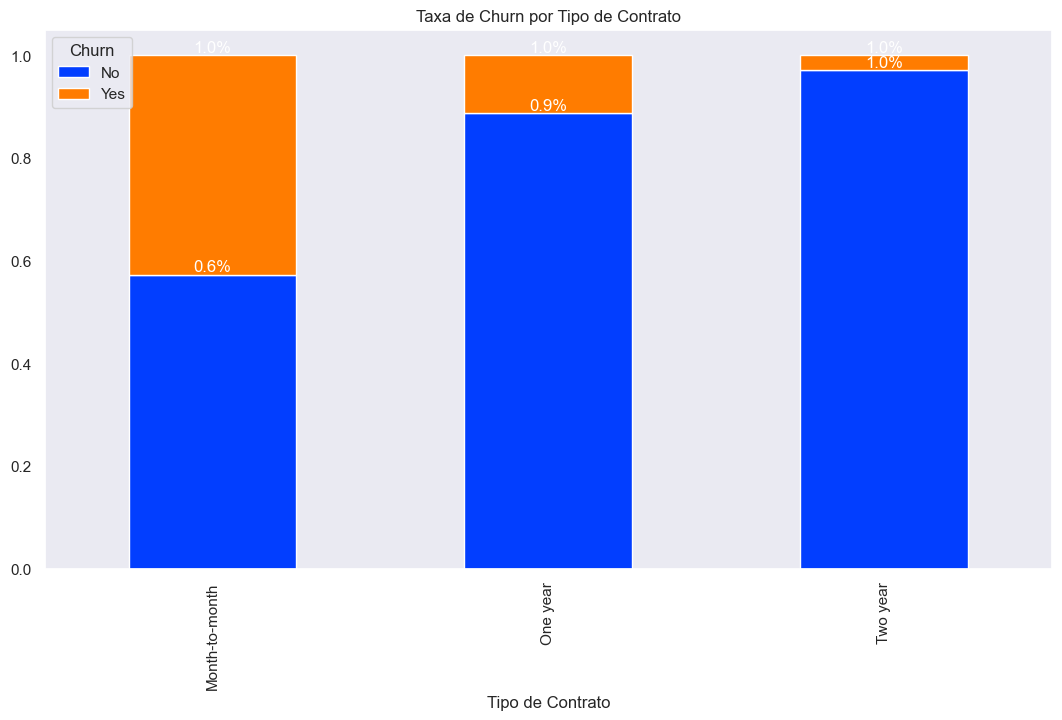

In [14]:
churn_rate = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
ax = churn_rate.plot(kind='bar', stacked=True, figsize=(13, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', color='white')

plt.title('Taxa de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('')
plt.legend(title='Churn')

plt.show()

In [15]:
(df.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Contract        Churn
Month-to-month  No       57.29%
                Yes      42.71%
One year        No       88.73%
                Yes      11.27%
Two year        No       97.17%
                Yes       2.83%
Name: proportion, dtype: object

### Agora iremos fazer alguns questionamentos e o responder utilizando os gráficos 

- 1. Qual seria a % dos clientes que estão cancelandos?

In [16]:
df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object

R: Não: 73.46%  /  Sim. 26.54%

- 2. Clientes novos cancelam mais?

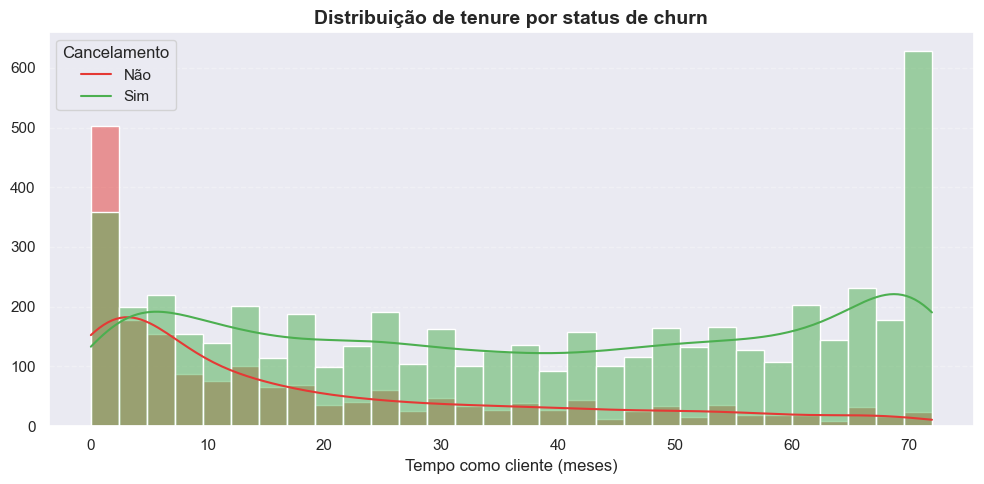

In [17]:
plt.figure(figsize=(10,5))

palette = {'No': '#4CAF50', 'Yes': '#E53935'}

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    palette=palette,
    alpha=0.5
)

plt.title('Distribuição de tenure por status de churn', fontsize=14, weight='bold')
plt.xlabel('Tempo como cliente (meses)')
plt.ylabel('')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Cancelamento', labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()

R: Clientes com menor tempo de contrato apresentam maior taxa de churn, indicando necessidade de ações de retenção nos primeiros meses

- 3. O tipo de contrato influencia no churn?

In [18]:
churn_rate = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .unstack()
)

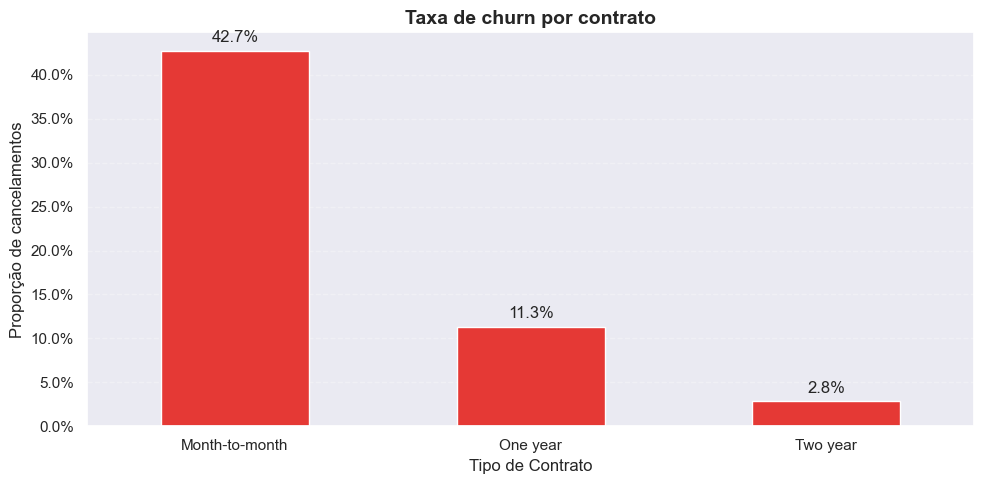

In [19]:
plt.figure(figsize=(10,5))

churn_rate['Yes'].plot(
    kind='bar',
    color='#E53935'
)

#sns.countplot(data=df, x='Contract', hue='Churn', palette=palette)

plt.title('Taxa de churn por contrato', fontsize=14, weight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Proporção de cancelamentos')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate['Yes']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- Sim, visto que clientes com contratos de longa data tendem a cancelar menos

- 4. Clientes pagam mais cancelam mais?

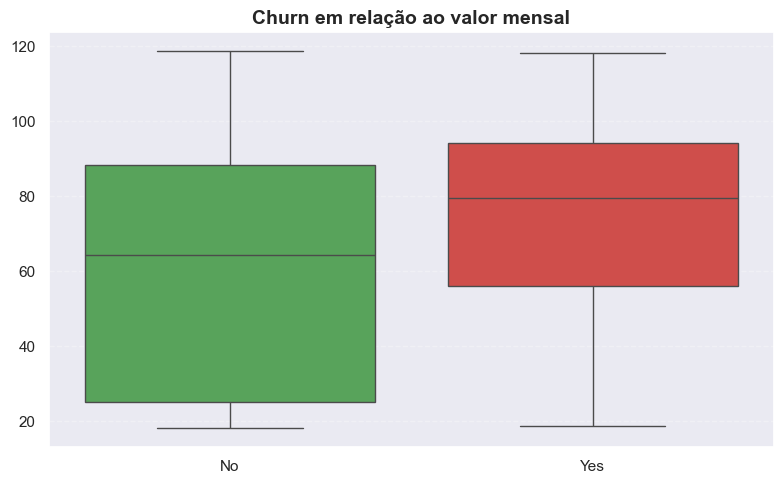

In [20]:
plt.figure(figsize=(8,5))

palette = {'No': '#4CAF50', 'Yes': '#E53935'}

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    hue='Churn',
    palette=palette
)

plt.title('Churn em relação ao valor mensal', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Clientes com maior valor mensal tendem a apresentar maior dispersão e leve tendência ao churn, indicando possível sensibilidade a preço

- 5. O tempo de cliente reduz churn?

In [21]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-12', '12-24', '24-48', '48-60', '60-72']
)

In [22]:
churn_rate = (
    df.groupby('tenure_group')['Churn']
    .value_counts(normalize=True)
    .unstack()
)

C:\Users\rexpe\AppData\Local\Temp\ipykernel_11548\2746023980.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn']


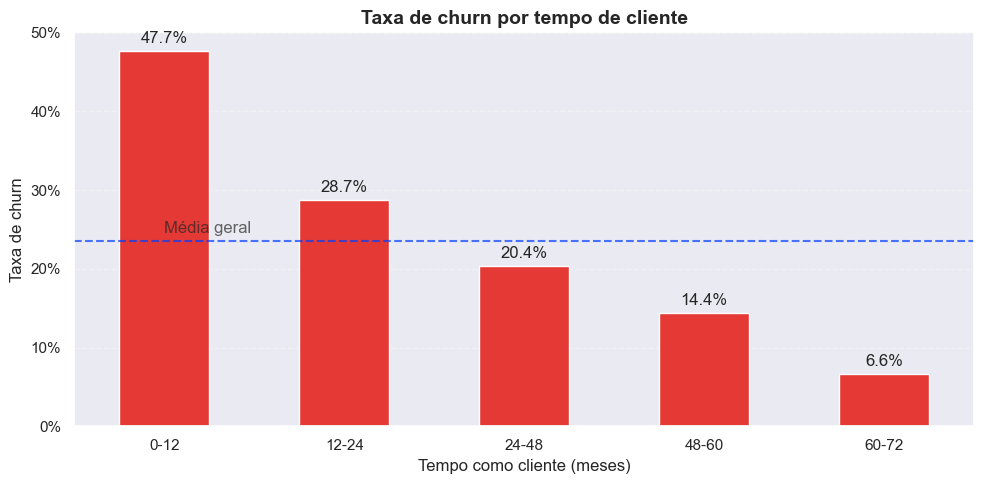

In [23]:
plt.figure(figsize=(10,5))

palette = '#E53935'

churn_rate['Yes'].plot(
    kind='bar',
    color=palette
)

plt.title('Taxa de churn por tempo de cliente', fontsize=14, weight='bold')
plt.xlabel('Tempo como cliente (meses)')
plt.ylabel('Taxa de churn')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate['Yes']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')


plt.axhline(y=churn_rate['Yes'].mean(), linestyle='--', alpha=0.7)
plt.text(0, churn_rate['Yes'].mean()+0.01, 'Média geral', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

- Clientes antigos tendem a ficar.

- 6. O tipo de internet influencia churn?

In [24]:
df_internet = df[df['InternetService'] != 'No']

churn_rate = (
    df_internet.groupby('InternetService')['Churn']
    .value_counts(normalize=True)
    .unstack()
)

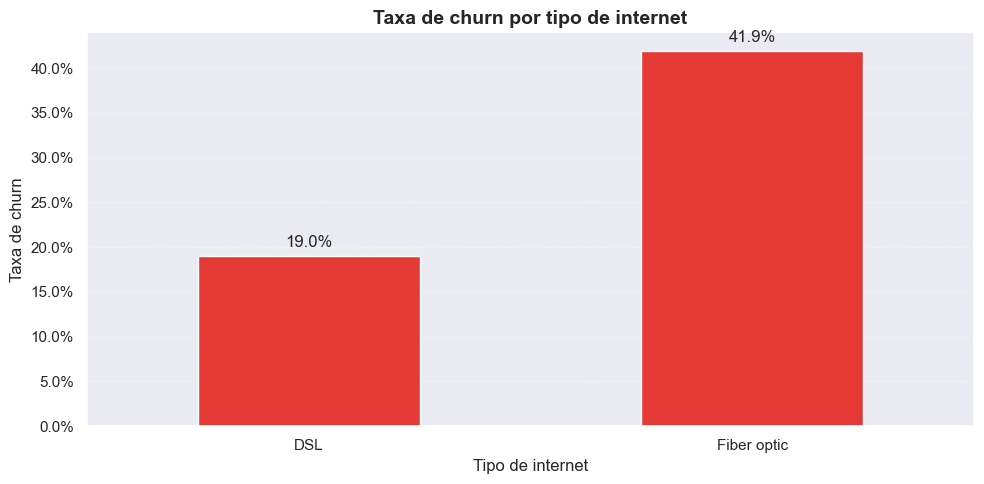

In [25]:
plt.figure(figsize=(10,5))

churn_rate['Yes'].plot(
    kind='bar',
    color='#E53935'
)

plt.title('Taxa de churn por tipo de internet', fontsize=14, weight='bold')
plt.xlabel('Tipo de internet')
plt.ylabel('Taxa de churn')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate['Yes']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

- O serviço Fibra Óptica pode gerar mais cancelamento.

- 7. O método de pagamento influencia churn?

In [26]:
churn_rate = (
    df.groupby('PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .unstack()
)

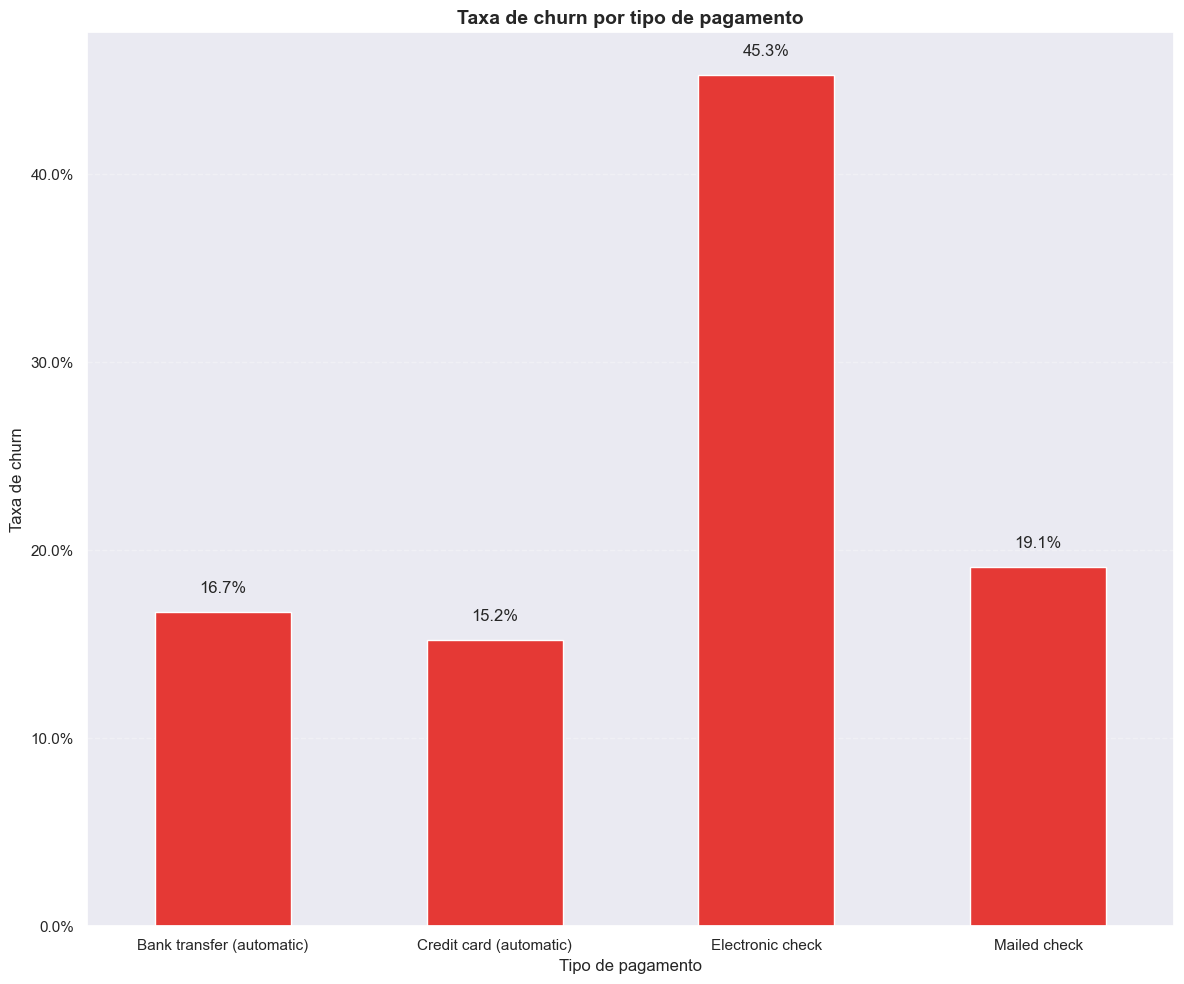

In [27]:
plt.figure(figsize=(12, 10))

churn_rate['Yes'].plot(
    kind='bar',
    color='#E53935'
)

plt.title('Taxa de churn por tipo de pagamento', fontsize=14, weight='bold')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Taxa de churn')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate['Yes']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


- Pagamento automático geralmente tem menor churn e o boleto costuma ter mais

- 8. Clientes com suporte técnico cancelam menos?

In [28]:
df_techsupport = df[df['TechSupport'] != 'No internet service']

churn_rate = (
    df_techsupport.groupby('TechSupport')['Churn']
    .value_counts(normalize=True)
    .unstack()
)

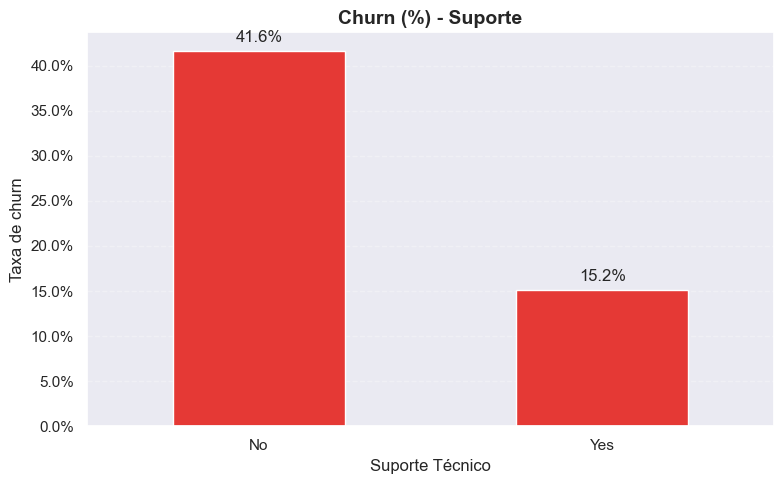

In [29]:
plt.figure(figsize=(8, 5))

churn_rate['Yes'].plot(
    kind='bar',
    color='#E53935'
)

plt.title('Churn (%) - Suporte', fontsize=14, weight='bold')
plt.xlabel('Suporte Técnico')
plt.ylabel('Taxa de churn')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate['Yes']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


- Não ter suporte ténico é um fator muito grande para o churn, visto que os clientes ficam sem suporte quando ocorrer problemas que não tem conhecimento para arrumar ou ferramentas

- 9. Clientes com parceiros ou família cancelam menos?

In [30]:
churn_rate = (
    df.groupby('Partner')['Churn']
    .value_counts(normalize=True)
    .unstack()
)

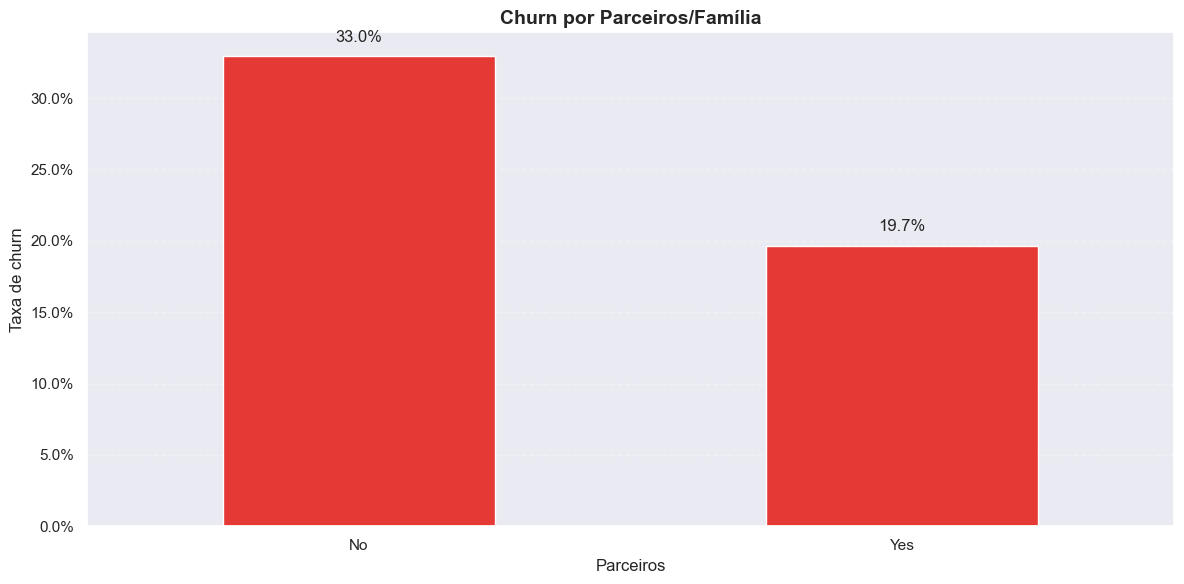

In [31]:
plt.figure(figsize=(12, 6))

churn_rate['Yes'].plot(
    kind='bar',
    color='#E53935'
)

plt.title('Churn por Parceiros/Família', fontsize=14, weight='bold')
plt.xlabel('Parceiros')
plt.ylabel('Taxa de churn')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate['Yes']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


- Não parecem ter tanta relevancia mas parceiros com familia tem maior estabilidade para manter, assim tendo um churn menor

- 10. Existe relação entre preço total pago e churn?

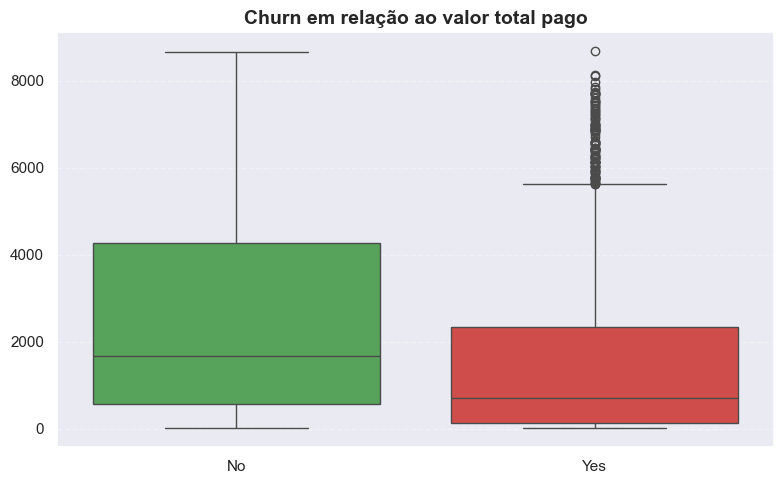

In [32]:
plt.figure(figsize=(8,5))

palette = {'No': '#4CAF50', 'Yes': '#E53935'}

sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges',
    hue='Churn',
    palette=palette
)

plt.title('Churn em relação ao valor total pago', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


- Clientes com maior investimento podem cancelar menos.